### Numpy array VS Python Lists


In [1]:
# speed test

import time

a = [i for i in range(10000000)]
b = [i for i in range(10000000,20000000)]
c = []
start = time.time()
for i in range(len(a)):
    c.append(a[i]+b[i])
end = time.time()
print(f'{end-start:.4f}')

2.5636


In [2]:
# numpy
import numpy as np
a = np.arange(10000000)
b = np.arange(10000000,20000000)

start = time.time()
c = a + b
print(time.time()-start)

0.21142029762268066


In [3]:
# memory
a = [i for i in range(10000000)]
import sys

sys.getsizeof(a)

89095160

In [4]:
a = np.arange(10000000 , dtype = np.int8)
sys.getsizeof(a)

10000112

### Advanced Indexing

In [5]:
# Normal Indexing and slicing
a = np.arange(24).reshape((6,4))
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [6]:
a[1,2]

np.int64(6)

In [7]:
a[1:3 , 1:3]

array([[ 5,  6],
       [ 9, 10]])

In [8]:
# Fancy Indexing

a[: , [0,2,3]]

array([[ 0,  2,  3],
       [ 4,  6,  7],
       [ 8, 10, 11],
       [12, 14, 15],
       [16, 18, 19],
       [20, 22, 23]])

In [9]:
# Boolean Indexing

a = np.random.randint(1,100,24).reshape(6,4)
a

array([[82, 73, 30, 88],
       [26,  4, 69, 77],
       [82, 84, 64, 10],
       [36, 42, 79, 47],
       [77, 25, 52, 95],
       [95, 87, 88, 21]], dtype=int32)

In [10]:
# Find all the numbers > 50

a[a>50]

array([82, 73, 88, 69, 77, 82, 84, 64, 79, 77, 52, 95, 95, 87, 88],
      dtype=int32)

In [11]:
# Find all the even numbers
a[a%2 == 0]

array([82, 30, 88, 26,  4, 82, 84, 64, 10, 36, 42, 52, 88], dtype=int32)

In [12]:
# find all numbers greater than 50 and are even

a[(a > 50) & (a % 2 == 0)]

array([82, 88, 82, 84, 64, 52, 88], dtype=int32)

In [13]:
# Find all the numbers not divisible by 7
a[~(a%7 == 0)]

array([82, 73, 30, 88, 26,  4, 69, 82, 64, 10, 36, 79, 47, 25, 52, 95, 95,
       87, 88], dtype=int32)

### Broadcasting
- The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.
- The smaller array is 'broadcast' across larger array so that they have compatible shapes

In [14]:
# same shape

a = np.arange(6).reshape(2,3)
b = np.arange(6,12).reshape(2,3)
print(a)
print(b)

print('add\n',a+b)

[[0 1 2]
 [3 4 5]]
[[ 6  7  8]
 [ 9 10 11]]
add
 [[ 6  8 10]
 [12 14 16]]


In [15]:
# diff shape

a = np.arange(6).reshape(2,3)
b = np.arange(3).reshape(1,3)
print(a)
print(b)

print('add\n',a+b)

[[0 1 2]
 [3 4 5]]
[[0 1 2]]
add
 [[0 2 4]
 [3 5 7]]


### Broadcasting Rules :- 
- **1. Make the two arrays have the same number of dimensions:-**.
    - If the Number of dimesions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.
- **2. Make each dimension of the two arrays the same size**.
    - If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
    - ***If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.***

<img src = "https://jakevdp.github.io/PythonDataScienceHandbook/figures/02.05-broadcasting.png">

In [16]:
# More Examples
a = np.arange(12).reshape(4,3)
b = np.arange(3)
print(a)
print(b)
# print(a.shape)
# print(b.shape)
print(a+b)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[0 1 2]
[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [17]:
a = np.arange(12).reshape(3,4)
b = np.arange(3)

print(a)
print(b)

print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[0 1 2]


ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

In [ ]:
a = np.arange(3).reshape(1,3)
b = np.arange(3).reshape(3,1)

print(a)
print(b)

print(a+b)

[[0 1 2]]
[[0]
 [1]
 [2]]
[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [ ]:
a = np.arange(3).reshape(1,3)
b = np.arange(4).reshape(4,1)

print(a)
print(b)

print(a + b)

[[0 1 2]]
[[0]
 [1]
 [2]
 [3]]
[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]


In [ ]:
a = np.array([1])
# shape -> (1,1)
b = np.arange(4).reshape(2,2)
# shape -> (2,2)

print(a)
print(b)

print(a+b)

[1]
[[0 1]
 [2 3]]
[[1 2]
 [3 4]]


In [ ]:
a = np.arange(12).reshape(3,4)
b = np.arange(12).reshape(4,3)

print(a)
print(b)

print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


ValueError: operands could not be broadcast together with shapes (3,4) (4,3) 

In [ ]:
a = np.arange(16).reshape(4,4)
b = np.arange(4).reshape(2,2)

print(a)
print(b)

print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[0 1]
 [2 3]]


ValueError: operands could not be broadcast together with shapes (4,4) (2,2) 

### Working with mathematical formulaes

In [ ]:
a = np.arange(10)
np.sin(a)

array([ 0.        ,  0.84147098,  0.90929743,  0.14112001, -0.7568025 ,
       -0.95892427, -0.2794155 ,  0.6569866 ,  0.98935825,  0.41211849])

In [ ]:
# sigmoid

def sigmoid(array):
    return 1/(1 + np.exp(-(array)))

a = np.arange(100)
sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661,
       0.9999546 , 0.9999833 , 0.99999386, 0.99999774, 0.99999917,
       0.99999969, 0.99999989, 0.99999996, 0.99999998, 0.99999999,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

In [ ]:
# mean squared error

actual = np.random.randint(1,50,25)
predicted = np.random.randint(1,50,25)

In [ ]:
def mse(actual,predicted):
  return np.mean((actual - predicted)**2)

mse(actual,predicted)

np.float64(375.68)

In [ ]:
# binary cross entropy
np.mean((actual - predicted)**2)

np.float64(375.68)

In [ ]:
actual

array([43,  8, 16, 11, 41, 22, 32, 38, 19, 14, 45, 30, 47, 18,  8,  5, 16,
       46,  7, 10,  1, 16, 37, 39, 39], dtype=int32)

### Working with missing values

In [ ]:

a = np.array([1,2,3,4,np.nan,6])
a

array([ 1.,  2.,  3.,  4., nan,  6.])

In [ ]:
a[~np.isnan(a)]

array([1., 2., 3., 4., 6.])

### Plotting Graphs

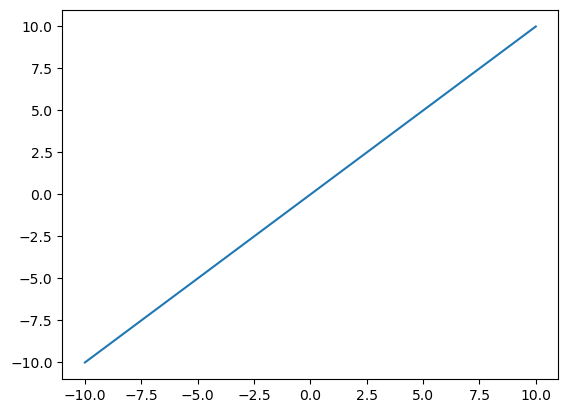

In [ ]:
# Plotting 2D graph
# x = y
# !pip install matplotlib
import matplotlib.pyplot as plt

x = np.linspace(-10,10,100)
y = x
plt.plot(x,y)

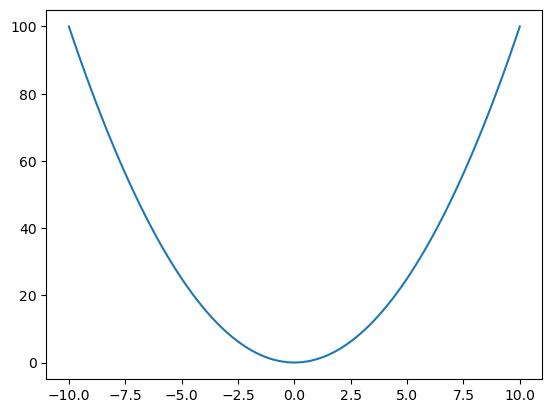

In [ ]:
# y = x^2
x = np.linspace(-10,10,100)
y = x**2

plt.plot(x,y)

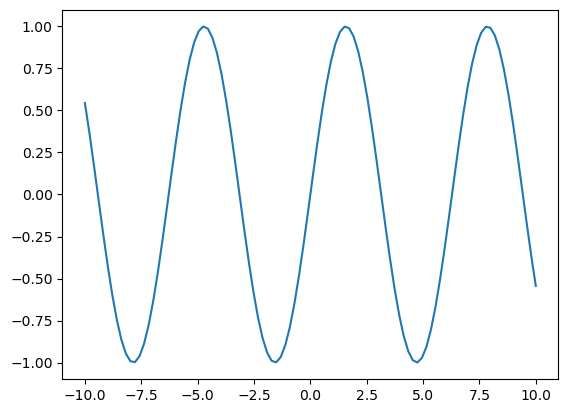

In [ ]:
# y = sin(x)
x = np.linspace(-10,10,100)
y = np.sin(x)

plt.plot(x,y)

C:\Users\hites\AppData\Local\Temp\ipykernel_876\2564014901.py:3: RuntimeWarning: invalid value encountered in log
  y = x * np.log(x)


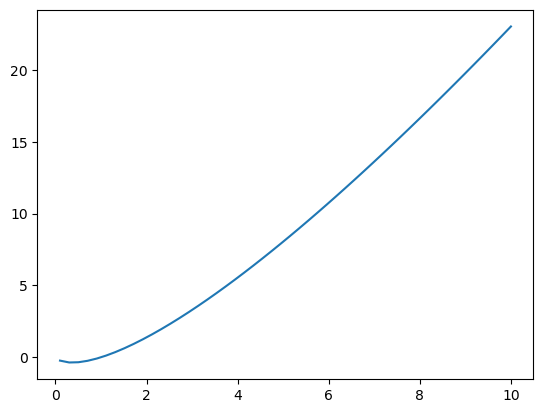

In [ ]:
# y = xlog(x)
x = np.linspace(-10,10,100)
y = x * np.log(x)

plt.plot(x,y)

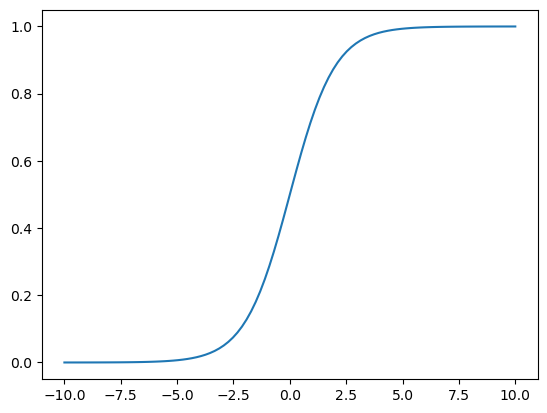

In [ ]:
# sigmoid
x = np.linspace(-10,10,100)
y = 1/(1+np.exp(-x))

plt.plot(x,y)

### Meshgrids
The np.meshgrid function takes two 1D arrays (representing the coordinates along the x-axis and y-axis) and returns two 2D matrices. These matrices contain the full grid of $(x, y)$ coordinate pairs across the entire area.Why do you need it next?Up until now in your notebook, you have been working with a single independent variable $x$ to calculate a single dependent variable $y$ (a 1D line plot):$$\text{Line: } y = f(x)$$Meshgrids are the gateway to evaluating functions of two variables, where a depth or height $z$ depends on both $x$ and $y$:$$\text{Surface/Grid: } z = f(x, y)$$Common Use CasesOnce you implement np.meshgrid in that empty cell, you will typically use it for:Contour Plots (plt.contour / plt.contourf): Visualizing topographic-like lines or density maps.3D Surface Plots: Plotting 3D valleys, peaks, or shapes.Vector Fields: Plotting gradient directions or physics fields (like electric/magnetic fields).

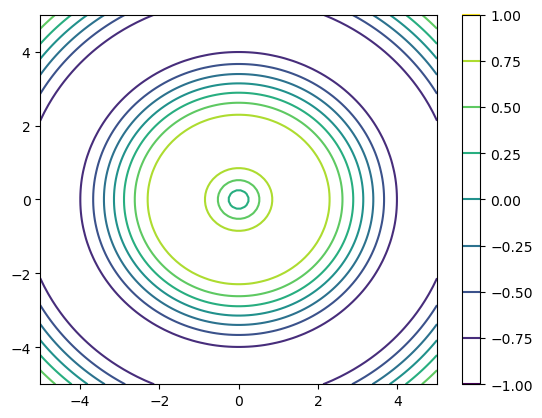

In [ ]:
# 1. Create 1D coordinate vectors
x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)

# 2.  Generate 2D grid
X,Y = np.meshgrid(x,y)

# 3. Evaluate a 2D function (e.g., a 3D wave or paraboloid)
Z = np.sin(np.sqrt(X**2 + Y**2))

plt.contour(X,Y,Z,cmap='viridis')
plt.colorbar()
plt.show()